# Multi-Model AutoML LOOCV — Morph @ FC ROI 4개 (교차)

각 모델을 **두 데이터셋에 동일하게** 적용해 1:1로 비교합니다.
- **Clinical_ONLY**: `vas_t0`, `treatment_group` (2개)
- **Brain_Plus_Clinical**: 위 2개 + **FC 쪽 ROI 4개의 피질 두께** (Residualized)
- **제거 변수**: age, sex, eTIV / **타겟**: vas_t1

이전 버전은 Baseline만 튜닝 없이 돌려서, 성능 차이가 뇌 지표 때문인지
튜닝 때문인지 구분되지 않았습니다. 이제 두 데이터셋 모두 같은 모델·같은 GridSearchCV를 거칩니다.

---
## 이 노트북은 ROI 목록을 **교차**시킨 것이다

원래 두 모달리티는 서로 다른 근거로 ROI를 골랐고, 목록이 거의 겹치지 않는다.

| | ROI 선정 근거 | 목록 |
|---|---|---|
| **Morph ROI 10** | 중독 문헌의 보상회로 | rostralmiddlefrontal(좌우), Caudate·Putamen·Accumbens(좌우), lateralOFC(좌), rostralACC(좌) |
| **FC ROI 4** | Nature Mental Health 2024(같은 코호트)가 이름을 명시한 Schaefer 파셀 4개를 centroid 거리로 DK에 매핑 | medialOFC(좌), caudalACC(우), bankssts(좌), lateralOFC(우) |

그래서 **"영역 선정이 중요한가, 모달리티가 중요한가"** 를 가리려면 네 칸을 다 채워야 한다.

| | Morph ROI 10 | FC ROI 4 |
|---|---|---|
| **Morph** (두께/부피) | `../automl_comparison_paired_ROI10.ipynb` | `roi_crossover/automl_comparison_paired_ROI4_morph.ipynb` |
| **FC** (node strength) | `roi_crossover/automl_comparison_paired_FC_ROI10_strength.ipynb` | `../automl_comparison_paired_FC_ROI_strength.ipynb` |

대각선(각자 자기 근거로 고른 ROI)이 비대각선(교차)보다 좋아야 "그 목록이 그 모달리티에 특화됐다"고 말할 수 있다.

## 측정치 규칙 — 왜 한쪽만 고민거리인가

두 모달리티가 ROI에서 꺼내 쓰는 값의 종류가 다르다.

| | 쓰는 값 | 컬럼 예시 |
|---|---|---|
| Morph | 두께 `_thick` / 면적 `_area` / 부피 `_vol` | `lh_bankssts_thick` |
| FC | node strength 하나뿐 | `lh_bankssts_fc` |

FC는 ROI당 값이 **strength 하나**라 고를 것이 없다. 반면 Morph는 피질에서 두께와 면적 중 골라야 한다.
기존 ROI10이 **피질=두께, 피질하=부피**(ROI 하나당 측정치 하나)였으므로 그 규칙을 그대로 따른다.
면적을 더해 8개로 만들면 ROI 목록 말고 측정치 규칙까지 바뀌어, 성능 차이의 원인을 가릴 수 없다.

## 표본 수 주의

morph는 **n=45**, FC는 **n=44**다(sub-001은 ses-t0 fmriprep 크래시로 MNI preproc BOLD 없음).
네 칸을 나란히 놓을 때 이 차이를 함께 적어야 한다.


In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION
# ==========================================================
df = pd.read_csv('../structural_full_68_68_16_edited.csv', skipinitialspace=True)
df.columns = df.columns.str.strip()

# FC 쪽 ROI 4개를 Morph로 본다 (automl_comparison_paired_FC_ROI_strength.ipynb와 같은 영역)
#   FC는 ROI당 strength 하나뿐이지만 Morph는 두께/면적 중 골라야 한다.
#   ROI10 규칙(피질=두께)을 그대로 따라 두께만 쓴다. 4개 영역 모두 피질이다.
brain_regions = [
    'lh_medialorbitofrontal',        # 논문 LH LIM OFC 1
    'rh_caudalanteriorcingulate',    # 논문 RH Cont PFCmp 2
    'lh_bankssts',                   # 논문 LH DMN Temp 3
    'rh_lateralorbitofrontal',       # 논문 RH LIM OFC 1
]
morph_features = [f'{r}_thick' for r in brain_regions]
missing = [x for x in morph_features if x not in df.columns]
assert not missing, f'컬럼 없음: {missing}'

nuisance_covariates = ['age', 'sex', 'eTIV']
clinical_predictors = ['vas_t0', 'treatment_group']
target = 'vas_t1'

X_morph = df[morph_features].values
X_nuisance = df[nuisance_covariates].values
X_clinical = df[clinical_predictors].values
y = df[target].values
print(f'n = {len(df)},  brain features = {X_morph.shape[1]}')
print(morph_features)

n = 45,  brain features = 4
['lh_medialorbitofrontal_thick', 'rh_caudalanteriorcingulate_thick', 'lh_bankssts_thick', 'rh_lateralorbitofrontal_thick']


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP
# ==========================================================
# [변경] Baseline 항목 삭제. 모든 모델이 두 데이터셋에 동일하게 적용됨.
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],   # 위로 확장
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]    # 아래로 확장
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]                # 위로
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로 (최우선)
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],        # 아래로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]                        # split보다 leaf가 n작을 때 효과적
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],                                 # n=45면 5는 과함
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]                                # 규제 추가
    },
}

DATA_TYPES = ['Clinical_ONLY', 'Brain_Plus_Clinical']

In [4]:
X_morph.shape

(45, 4)

In [5]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
# ==========================================================
loo = LeaveOneOut()
# [변경] 예측을 (데이터셋, 모델) 조합별로 저장
predictions = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_morph)):
    print(f"Processing fold {fold_idx+1}/{len(y)}...", end='\r')

    X_m_train, X_m_test = X_morph[train_idx], X_morph[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- Nuisance Residualization ---
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_m_train)
    X_m_train_clean = X_m_train - nuisance_regressor.predict(X_n_train)
    X_m_test_clean = X_m_test - nuisance_regressor.predict(X_n_test)

    # --- Features Stack ---
    X_train_full = np.hstack([X_m_train_clean, X_c_train]) # 152 + 2 = 154 if all
    X_test_full = np.hstack([X_m_test_clean, X_c_test])

    y_true.append(y_test[0])

    # [변경] 두 데이터셋을 딕셔너리로 묶어 동일하게 처리
    raw_sets = {
        'Clinical_ONLY': (X_c_train, X_c_test),
        'Brain_Plus_Clinical': (X_train_full, X_test_full),
    }

    for dt, (X_tr_raw, X_te_raw) in raw_sets.items():
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr_raw)
        X_te = scaler.transform(X_te_raw)

        for name, model in models.items():
            inner_cv = GridSearchCV(model, param_grids[name], cv=3, # nested CV 최적은 결국 mse 기준으로 선택됨
                                    scoring='neg_mean_squared_error', n_jobs=1)
            inner_cv.fit(X_tr, y_train) 
            pred = inner_cv.best_estimator_.predict(X_te) # 외부 테스트
            predictions[(dt, name)].append(pred[0]) # 예측값 저장
            best_params_log[(dt, name)].append(str(inner_cv.best_params_))

print("\n\nLOOCV Completed.")

Starting LOOCV: 6 models x 2 datasets...





LOOCV Completed.


In [6]:
# ==========================================================
# 4. EVALUATION & PAIRED COMPARISON
# ==========================================================
y_true = np.array(y_true)

results = []
for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)
    corr, p_val = pearsonr(y_true, y_pred)
    results.append({
        'Data Type': dt,
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2 Score': r2_score(y_true, y_pred),
        'Pearson (r)': corr,
        'p-value': p_val,
    })
    

results_df = pd.DataFrame(results)

# --- 기준선: 평균만 예측하는 모델 ---
baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델의 LOOCV RMSE = {baseline_rmse:.3f}")
print("  -> 이 값보다 나쁜 모델은 예측력이 없는 것임\n")

# --- Paired 표 (행 = 모델, 열 = 데이터셋) ---
pivot = results_df.pivot(index='Model', columns='Data Type', values='RMSE')
pivot['dRMSE'] = pivot['Clinical_ONLY'] - pivot['Brain_Plus_Clinical']
pivot = pivot.sort_index()   # dRMSE 정렬 안 함

n_pos = int((pivot['dRMSE'] > 0).sum())  
n_tot = len(pivot)

print("========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========")
display(pivot)

print(f"\n부호 일관성: {n_tot}개 중 {n_pos}개가 +")
if n_pos == n_tot:
    print("  -> 전부 +. 알고리즘 선택과 무관하게 개선.")
elif n_pos == 0:
    print("  -> 전부 -. 뇌 지표가 오히려 해가 됨.")
else:
    print("  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.")
    print("  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== 전체 지표 ==========")
display(results_df.sort_values(['Model', 'Data Type']))

평균만 예측하는 모델의 LOOCV RMSE = 2.436
  -> 이 값보다 나쁜 모델은 예측력이 없는 것임

========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========


Data Type,Brain_Plus_Clinical,Clinical_ONLY,dRMSE
Model,,,
ElasticNet,2.204543,2.172883,-0.031660
LinearRegression,2.208629,2.175121,-0.033507
RandomForest,2.537726,2.469457,-0.068269
SVR_Linear,2.076014,2.165313,0.089299
SVR_RBF,2.069096,2.422185,0.353089
XGBoost,2.589851,2.419757,-0.170094



부호 일관성: 6개 중 2개가 +
  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.
  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.

========== 전체 지표 ==========


,Data Type,Model,RMSE,R2 Score,Pearson (r),p-value
7,Brain_Plus_Clinical,ElasticNet,2.204543,0.143471,0.408645,0.005321
1,Clinical_ONLY,ElasticNet,2.172883,0.167896,0.423841,0.003716
6,Brain_Plus_Clinical,LinearRegression,2.208629,0.140294,0.442431,0.002341
0,Clinical_ONLY,LinearRegression,2.175121,0.166181,0.424659,0.003643
10,Brain_Plus_Clinical,RandomForest,2.537726,-0.134996,0.116788,0.444860
4,Clinical_ONLY,RandomForest,2.469457,-0.074751,0.225351,0.136650
8,Brain_Plus_Clinical,SVR_Linear,2.076014,0.240434,0.511549,0.000329
2,Clinical_ONLY,SVR_Linear,2.165313,0.173684,0.439385,0.002530
9,Brain_Plus_Clinical,SVR_RBF,2.069096,0.245488,0.511284,0.000332
3,Clinical_ONLY,SVR_RBF,2.422185,-0.033997,0.263854,0.079883


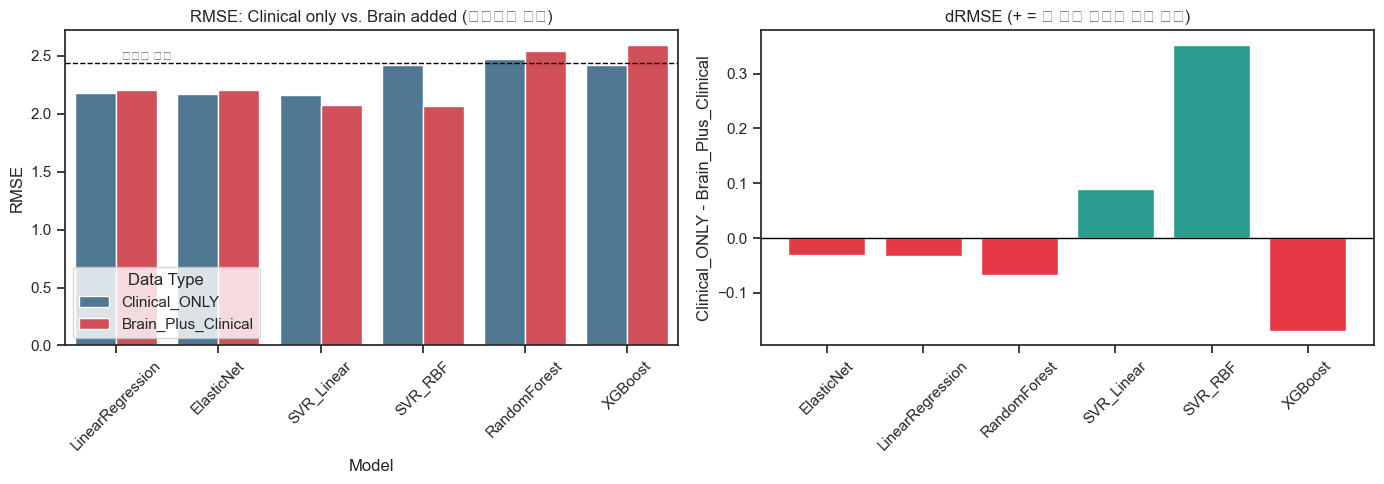

In [7]:
# ==========================================================
# 5. VISUALIZATION (Paired)
# ==========================================================
sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 모델별 RMSE를 데이터셋으로 나눠 나란히
sns.barplot(data=results_df, x='Model', y='RMSE', hue='Data Type',
            palette=['#457B9D', '#E63946'], ax=axes[0])
axes[0].axhline(baseline_rmse, color='black', linestyle='--', linewidth=1)
axes[0].text(0.02, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
axes[0].set_title('RMSE: Clinical only vs. Brain added (낮을수록 좋음)')
axes[0].tick_params(axis='x', rotation=45)

# 오른쪽: dRMSE
colors = ['#2A9D8F' if v > 0 else '#E63946' for v in pivot['dRMSE']]
axes[1].bar(pivot.index, pivot['dRMSE'], color=colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('dRMSE (+ = 뇌 지표 추가로 오차 감소)')
axes[1].set_ylabel('Clinical_ONLY - Brain_Plus_Clinical')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 6. 하이퍼파라미터 안정성 (선택 사항)
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{name} / {dt}] 고유 조합 {len(vc)}개, 최빈 {share:.0%}{flag}")

[LinearRegression / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[ElasticNet / Clinical_ONLY] 고유 조합 2개, 최빈 96%
[SVR_Linear / Clinical_ONLY] 고유 조합 11개, 최빈 33%   <-- 불안정
[SVR_RBF / Clinical_ONLY] 고유 조합 8개, 최빈 78%
[RandomForest / Clinical_ONLY] 고유 조합 6개, 최빈 67%
[XGBoost / Clinical_ONLY] 고유 조합 5개, 최빈 80%
[LinearRegression / Brain_Plus_Clinical] 고유 조합 1개, 최빈 100%
[ElasticNet / Brain_Plus_Clinical] 고유 조합 7개, 최빈 56%
[SVR_Linear / Brain_Plus_Clinical] 고유 조합 8개, 최빈 51%
[SVR_RBF / Brain_Plus_Clinical] 고유 조합 1개, 최빈 100%
[RandomForest / Brain_Plus_Clinical] 고유 조합 12개, 최빈 31%   <-- 불안정
[XGBoost / Brain_Plus_Clinical] 고유 조합 6개, 최빈 53%


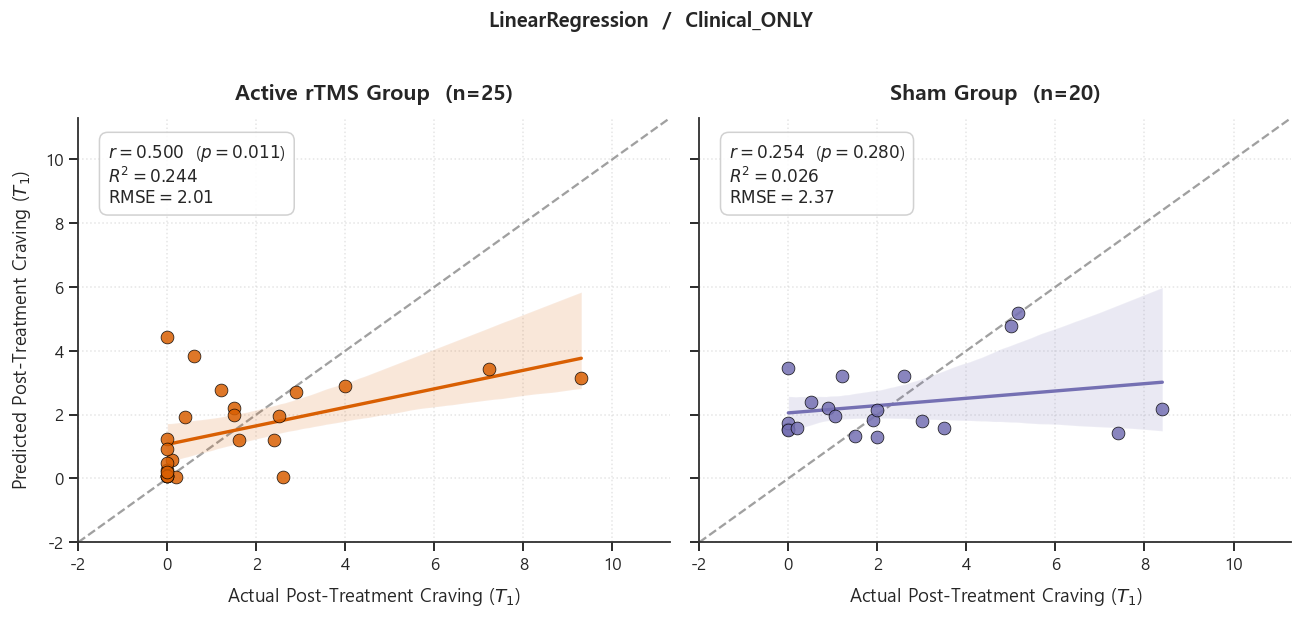

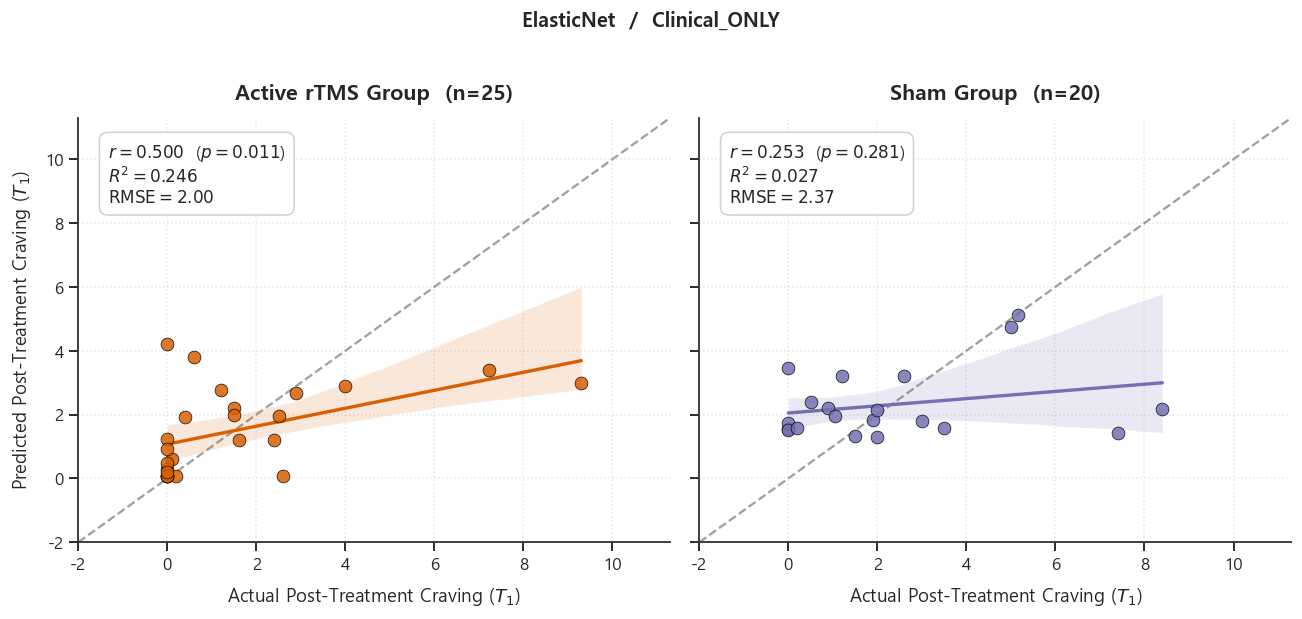

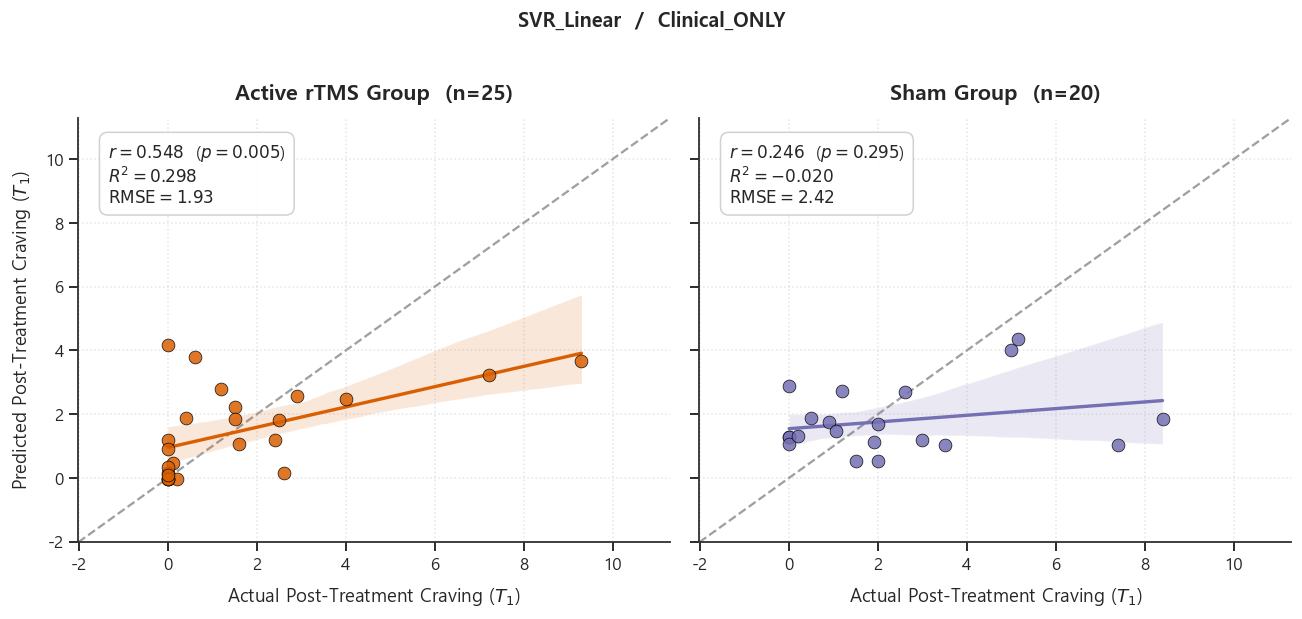

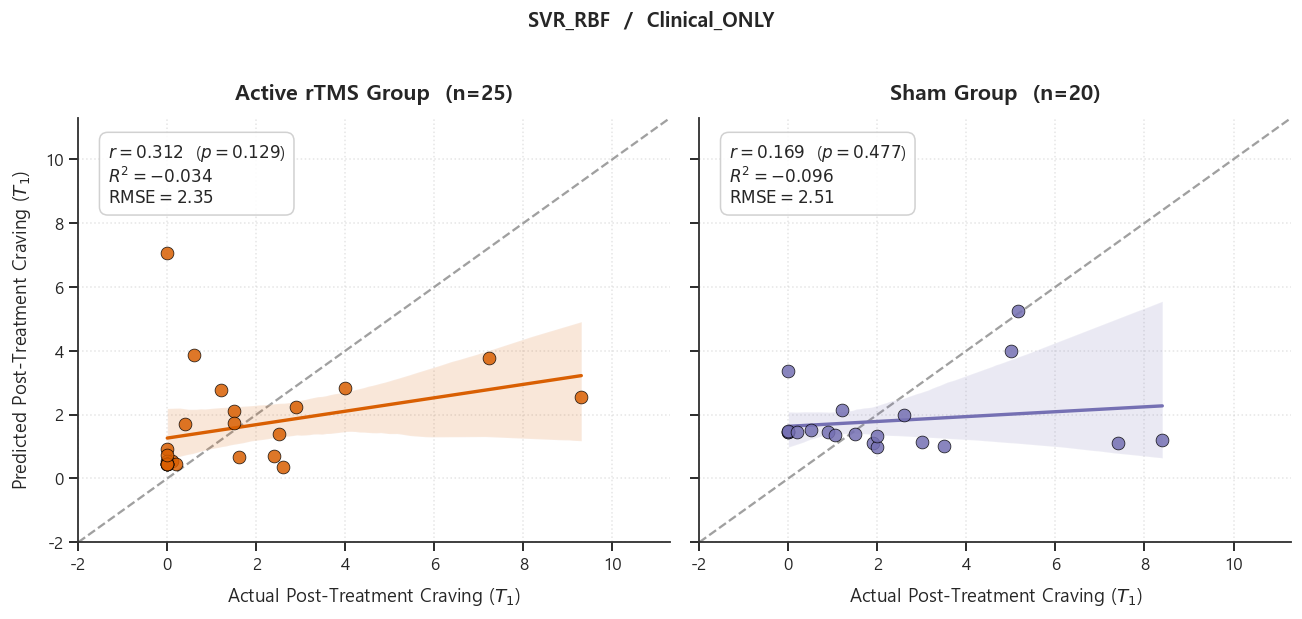

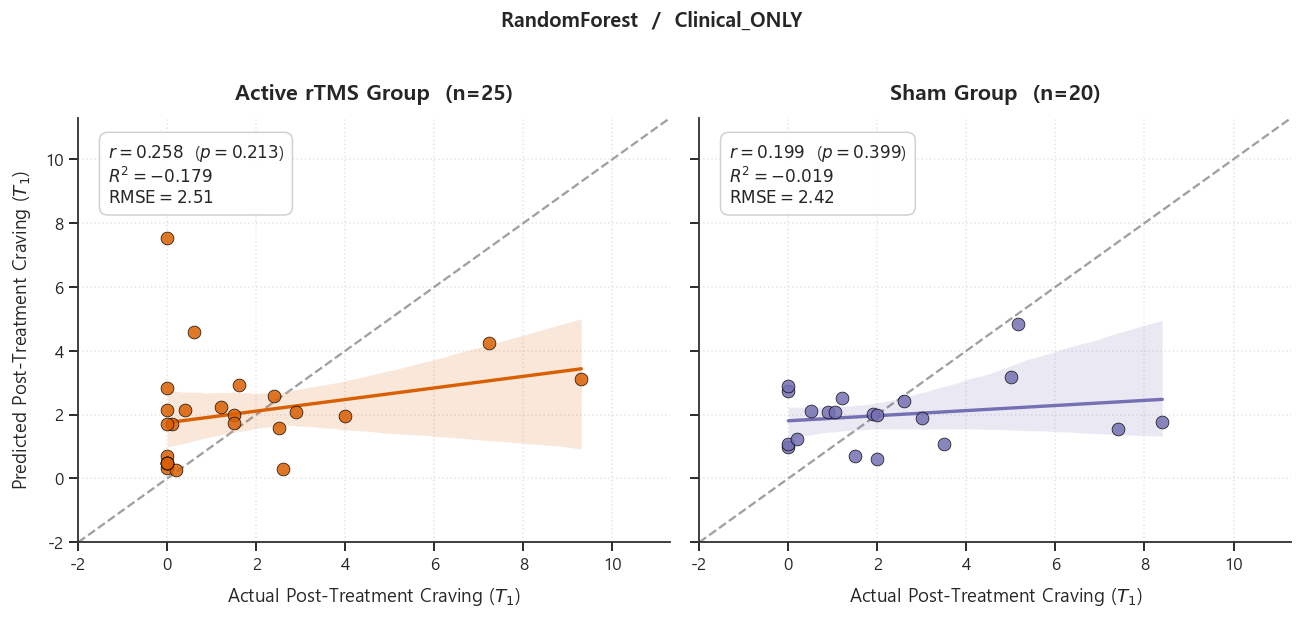

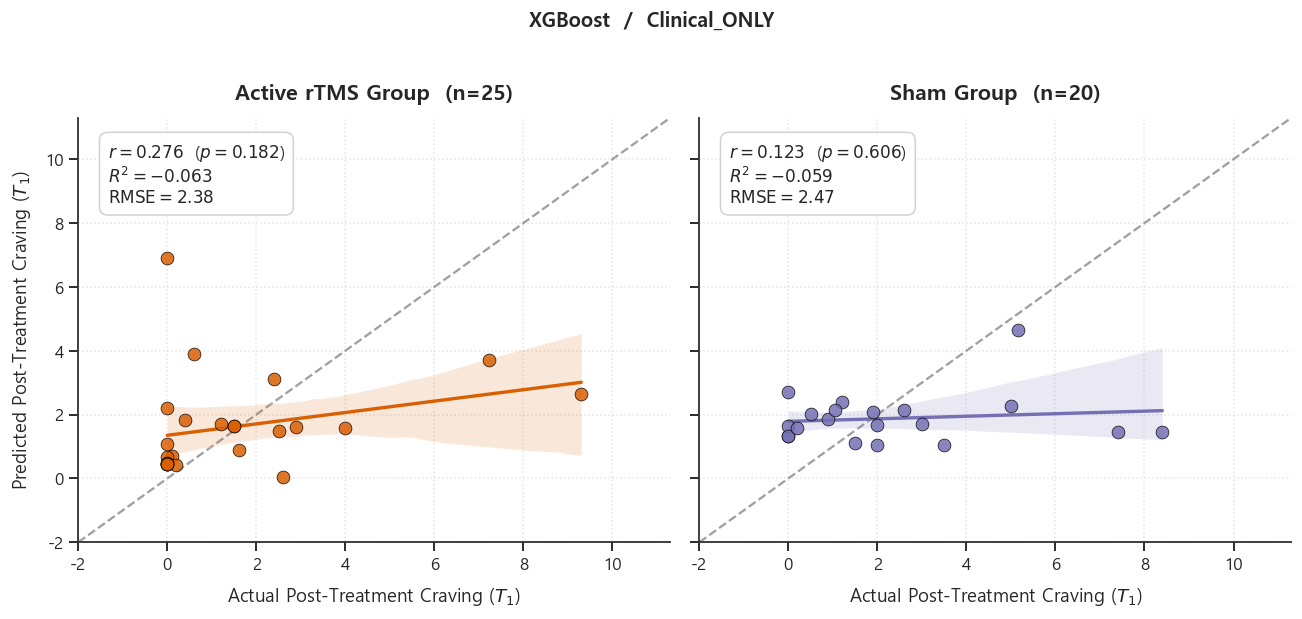

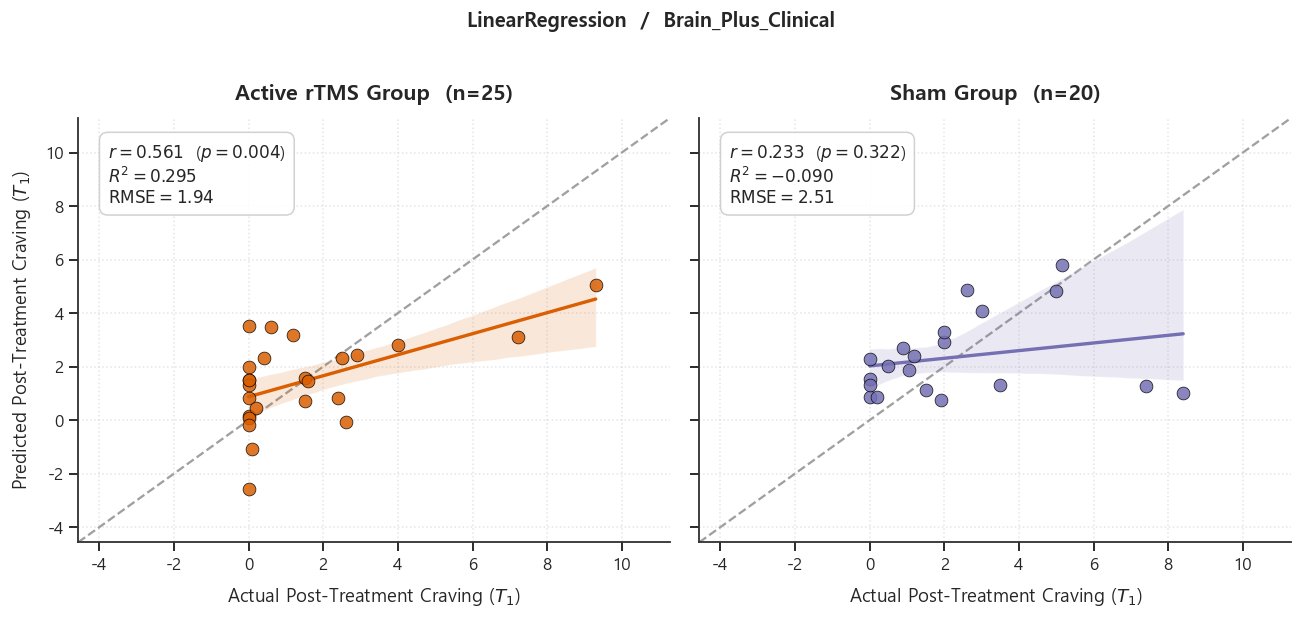

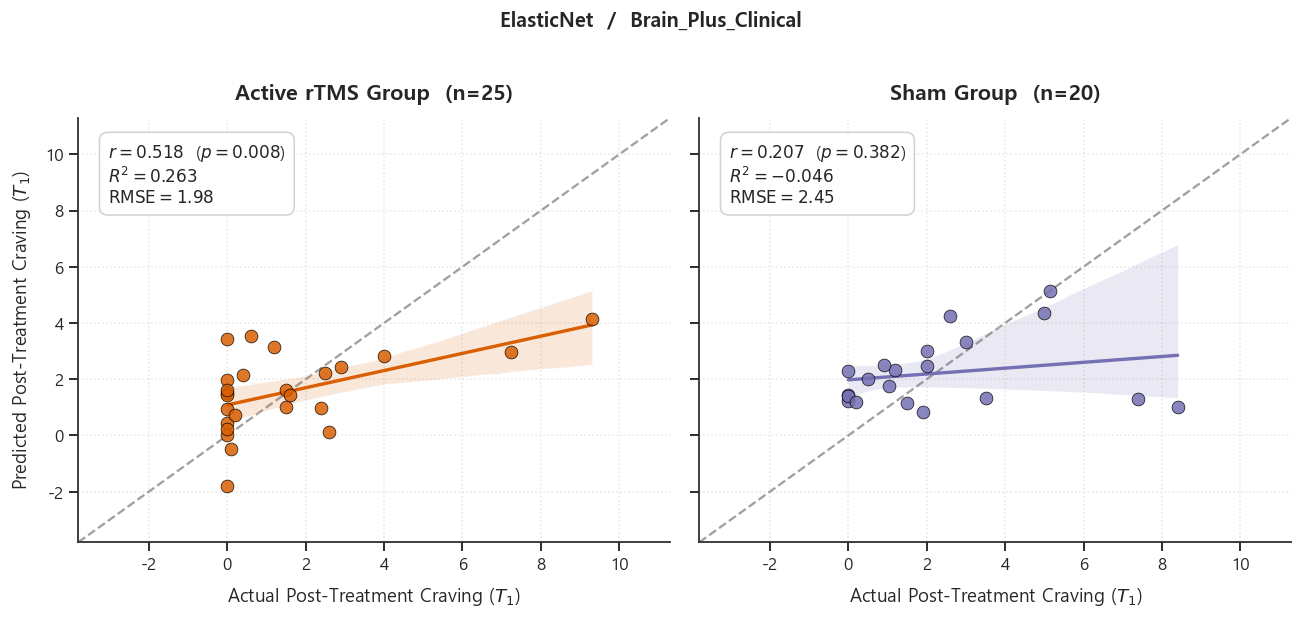

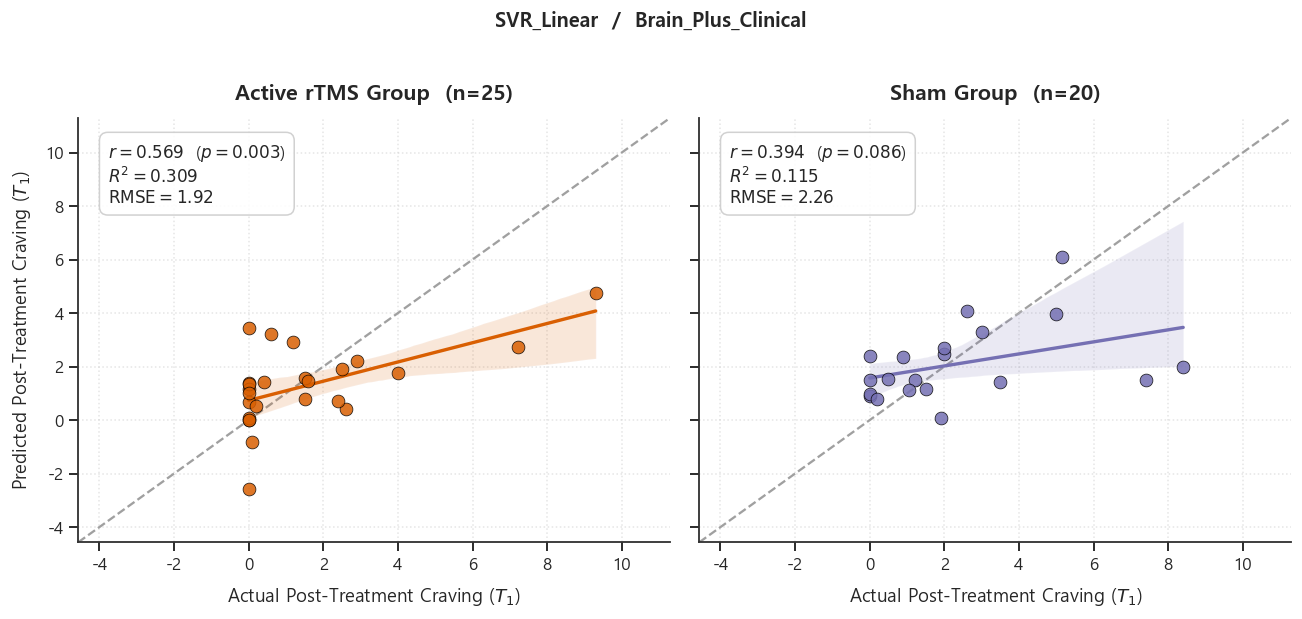

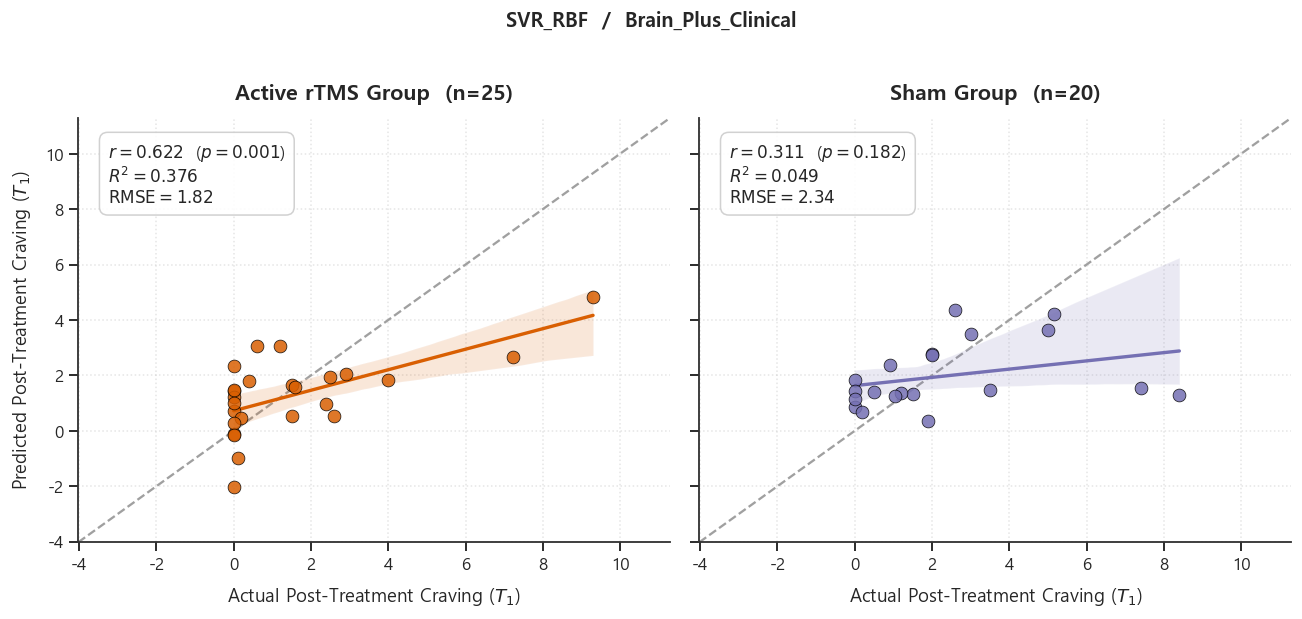

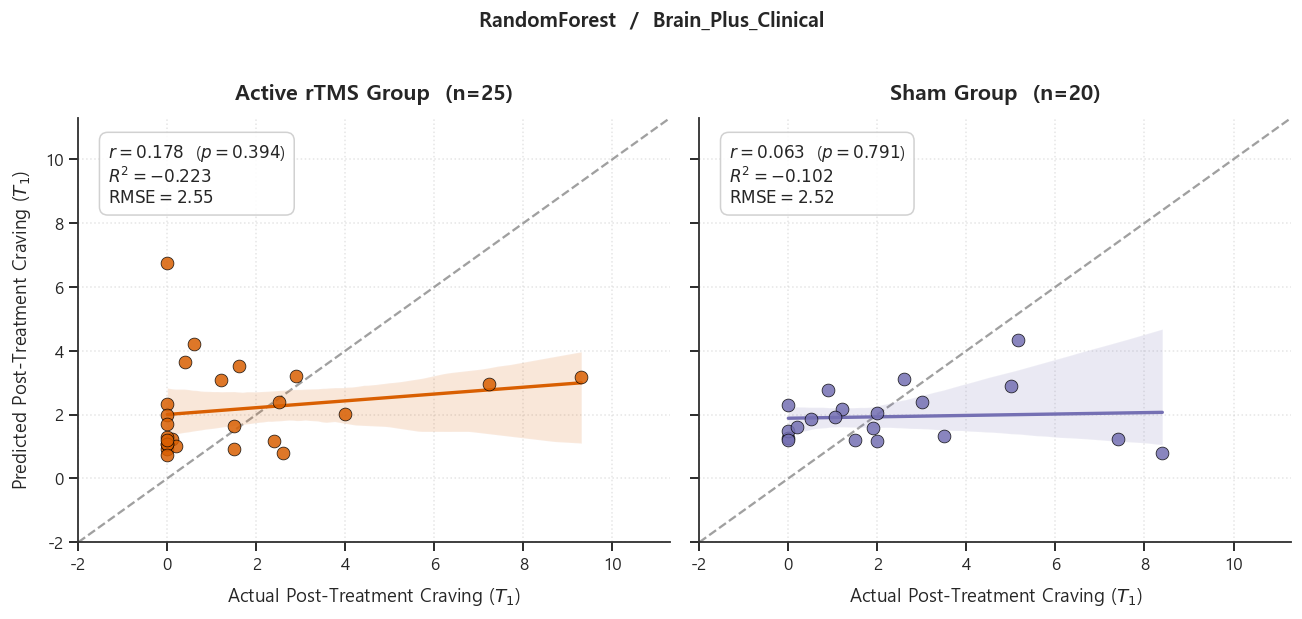

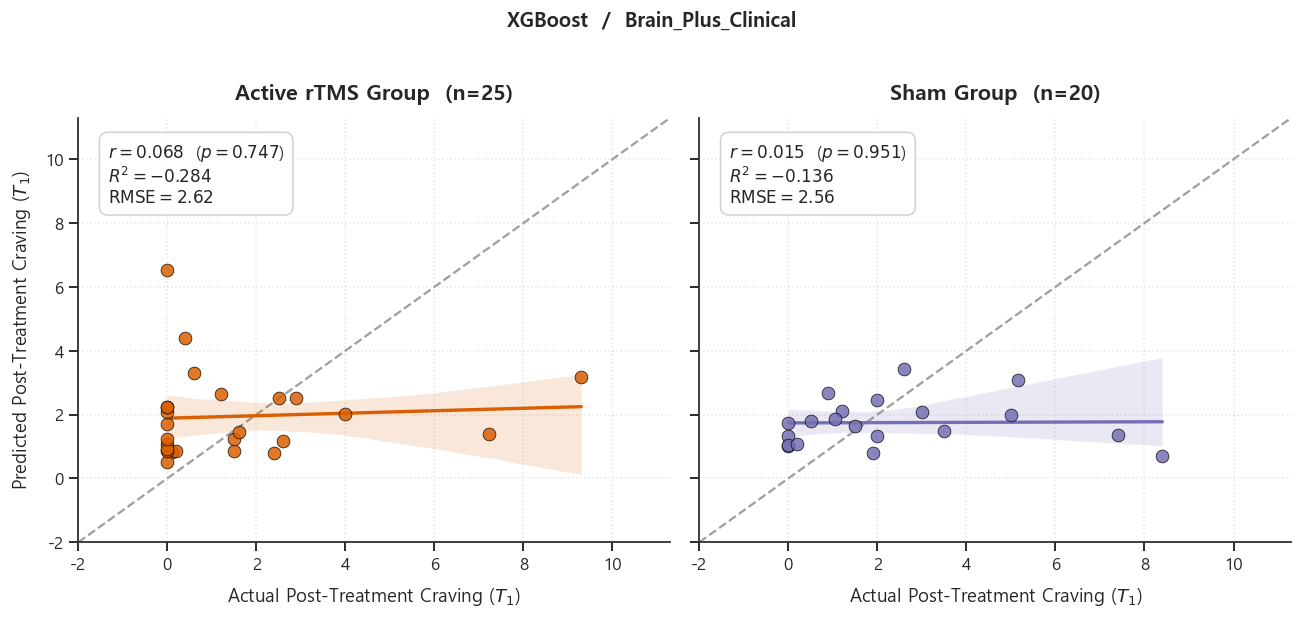

In [9]:
# ==========================================================
# 9. Active vs Sham — 12세트 전부
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'   # Helvetica는 Windows에 없음
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
groups = ['Active rTMS', 'Sham']

for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)

    plot_df = pd.DataFrame({
        'True_Craving': y,
        'Pred_Craving': y_pred,
        'Group': np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True, dpi=110)

    min_val = min(plot_df['True_Craving'].min(), plot_df['Pred_Craving'].min()) - 2
    max_val = max(plot_df['True_Craving'].max(), plot_df['Pred_Craving'].max()) + 2

    for i, grp in enumerate(groups):
        ax = axes[i]
        sub_df = plot_df[plot_df['Group'] == grp]
        color = palette[grp]

        r, pval = pearsonr(sub_df['True_Craving'], sub_df['Pred_Craving'])
        r2 = r2_score(sub_df['True_Craving'], sub_df['Pred_Craving'])
        rmse = np.sqrt(np.mean((sub_df['True_Craving'] - sub_df['Pred_Craving'])**2))

        ax.plot([min_val, max_val], [min_val, max_val],
                color='#A0A0A0', linestyle='--', linewidth=1.5, zorder=1)

        sns.scatterplot(
            data=sub_df, x='True_Craving', y='Pred_Craving',
            color=color, s=70, alpha=0.85, edgecolor='black',
            linewidth=0.5, ax=ax, zorder=3
        )

        sns.regplot(
            data=sub_df, x='True_Craving', y='Pred_Craving',
            ax=ax, scatter=False, color=color, line_kws={'linewidth': 2.2}, ci=95
        )

        ax.set_title(f'{grp} Group  (n={len(sub_df)})',
                     fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel('Actual Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
        if i == 0:
            ax.set_ylabel('Predicted Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)

        stats_text = (f"$r = {r:.3f}$  ($p = {pval:.3f}$)\n"
                      f"$R^2 = {r2:.3f}$\n"
                      f"$\\mathrm{{RMSE}} = {rmse:.2f}$")
        ax.text(
            0.05, 0.80, stats_text, transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      alpha=0.9, edgecolor='#CCCCCC')
        )

        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.grid(True, linestyle=':', alpha=0.5)

    fig.suptitle(f'{name}  /  {dt}', fontsize=13, fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [10]:
# ==========================================================
# 9-1. 산점도 결과 표 — 9번 셀의 r / R2 / RMSE 를 모델별로 정리
#      (그림에 찍힌 값과 같은 숫자다. 12장을 눈으로 비교하기 어려우니 표로 모은다)
# ==========================================================
group = np.where(df['treatment_group'].values == 2, 'Active', 'Sham')

rows_sc = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for g, m in [('Active', group == 'Active'), ('Sham', group == 'Sham')]:
        r, pv = pearsonr(y_true[m], yp[m])
        rows_sc.append({'Data Type': dt, 'Model': name, 'Group': g, 'n': int(m.sum()),
                        'RMSE': np.sqrt(np.mean((y_true[m] - yp[m]) ** 2)),
                        'R2': r2_score(y_true[m], yp[m]), 'r': r, 'p': pv})

sc = pd.DataFrame(rows_sc)
sc['Data Type'] = pd.Categorical(sc['Data Type'], DATA_TYPES)
sc['Model'] = pd.Categorical(sc['Model'], list(models))

wide = sc.pivot_table(index=['Data Type', 'Model'], columns='Group',
                      values=['RMSE', 'R2', 'r', 'p'], observed=True)
wide = wide.swaplevel(axis=1).sort_index(axis=1, level=0)
wide = wide[[('Active', k) for k in ['RMSE', 'R2', 'r', 'p']] +
            [('Sham', k) for k in ['RMSE', 'R2', 'r', 'p']]]

print(f"Active {int((group == 'Active').sum())}명 / Sham {int((group == 'Sham').sum())}명")
print("  RMSE는 낮을수록, r은 높을수록 좋다.")
print("  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).\n")
display(wide.round(3))

print("\n========== RMSE / r 만 추려보기 ==========")
slim = wide[[('Active', 'RMSE'), ('Sham', 'RMSE'), ('Active', 'r'), ('Sham', 'r')]].copy()
slim.columns = ['RMSE_Active', 'RMSE_Sham', 'r_Active', 'r_Sham']
slim['RMSE_diff'] = slim['RMSE_Active'] - slim['RMSE_Sham']   # 음수면 Active에서 오차가 작음
display(slim.round(3))

print("\n========== 군별 RMSE 상위 5 ==========")
for g in ['Active', 'Sham']:
    print(f'\n[{g}]')
    display(sc[sc.Group == g].sort_values('RMSE')[['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
            .round(3).head(5).reset_index(drop=True))

Active 25명 / Sham 20명
  RMSE는 낮을수록, r은 높을수록 좋다.
  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).



Group                                Active                        Sham  \
                                       RMSE     R2      r      p   RMSE   
Data Type           Model                                                 
Clinical_ONLY       LinearRegression  2.007  0.244  0.500  0.011  2.368   
                    ElasticNet        2.005  0.246  0.500  0.011  2.367   
                    SVR_Linear        1.934  0.298  0.548  0.005  2.423   
                    SVR_RBF           2.347 -0.034  0.312  0.129  2.513   
                    RandomForest      2.506 -0.179  0.258  0.213  2.423   
                    XGBoost           2.379 -0.063  0.276  0.182  2.469   
Brain_Plus_Clinical LinearRegression  1.938  0.295  0.561  0.004  2.506   
                    ElasticNet        1.982  0.263  0.518  0.008  2.455   
                    SVR_Linear        1.918  0.309  0.569  0.003  2.258   
                    SVR_RBF           1.823  0.376  0.622  0.001  2.340   
                    RandomForest      2.553 -0.223  0.178  0.394  2.519   
                    XGBoost           2.615 -0.284  0.068  0.747  2.557   

Group                                                      
                                         R2      r      p  
Data Type           Model                                  
Clinical_ONLY       LinearRegression  0.026  0.254  0.280  
                    ElasticNet        0.027  0.253  0.281  
                    SVR_Linear       -0.020  0.246  0.295  
                    SVR_RBF          -0.096  0.169  0.477  
                    RandomForest     -0.019  0.199  0.399  
                    XGBoost          -0.059  0.123  0.606  
Brain_Plus_Clinical LinearRegression -0.090  0.233  0.322  
                    ElasticNet       -0.046  0.207  0.382  
                    SVR_Linear        0.115  0.394  0.086  
                    SVR_RBF           0.049  0.311  0.182  
                    RandomForest     -0.102  0.063  0.791  
                    XGBoost          -0.136  0.015  0.951


========== RMSE / r 만 추려보기 ==========


RMSE_Active  RMSE_Sham  r_Active  \
Data Type           Model                                                
Clinical_ONLY       LinearRegression        2.007      2.368     0.500   
                    ElasticNet              2.005      2.367     0.500   
                    SVR_Linear              1.934      2.423     0.548   
                    SVR_RBF                 2.347      2.513     0.312   
                    RandomForest            2.506      2.423     0.258   
                    XGBoost                 2.379      2.469     0.276   
Brain_Plus_Clinical LinearRegression        1.938      2.506     0.561   
                    ElasticNet              1.982      2.455     0.518   
                    SVR_Linear              1.918      2.258     0.569   
                    SVR_RBF                 1.823      2.340     0.622   
                    RandomForest            2.553      2.519     0.178   
                    XGBoost                 2.615      2.557     0.068   

                                      r_Sham  RMSE_diff  
Data Type           Model                                
Clinical_ONLY       LinearRegression   0.254     -0.361  
                    ElasticNet         0.253     -0.362  
                    SVR_Linear         0.246     -0.489  
                    SVR_RBF            0.169     -0.166  
                    RandomForest       0.199      0.084  
                    XGBoost            0.123     -0.090  
Brain_Plus_Clinical LinearRegression   0.233     -0.567  
                    ElasticNet         0.207     -0.473  
                    SVR_Linear         0.394     -0.340  
                    SVR_RBF            0.311     -0.517  
                    RandomForest       0.063      0.034  
                    XGBoost            0.015      0.058


========== 군별 RMSE 상위 5 ==========

[Active]


,Data Type,Model,RMSE,R2,r,p
0,Brain_Plus_Clinical,SVR_RBF,1.823,0.376,0.622,0.001
1,Brain_Plus_Clinical,SVR_Linear,1.918,0.309,0.569,0.003
2,Clinical_ONLY,SVR_Linear,1.934,0.298,0.548,0.005
3,Brain_Plus_Clinical,LinearRegression,1.938,0.295,0.561,0.004
4,Brain_Plus_Clinical,ElasticNet,1.982,0.263,0.518,0.008



[Sham]


,Data Type,Model,RMSE,R2,r,p
0,Brain_Plus_Clinical,SVR_Linear,2.258,0.115,0.394,0.086
1,Brain_Plus_Clinical,SVR_RBF,2.340,0.049,0.311,0.182
2,Clinical_ONLY,ElasticNet,2.367,0.027,0.253,0.281
3,Clinical_ONLY,LinearRegression,2.368,0.026,0.254,0.280
4,Clinical_ONLY,RandomForest,2.423,-0.019,0.199,0.399


In [11]:
# ==========================================================
# 10. 군간 아티팩트 점검 — vas 분산 / 상관 구조가 다른가
# ==========================================================
from scipy.stats import levene

g = df['treatment_group'].values
vt0, vt1 = df['vas_t0'].values, df['vas_t1'].values

rows = []
for grp, code in [('Active', 2), ('Sham', 1)]:
    m = g == code
    r_raw, p_raw = pearsonr(vt0[m], vt1[m])
    rows.append({
        'group': grp, 'n': m.sum(),
        'vas_t0_mean': vt0[m].mean(), 'vas_t0_SD': vt0[m].std(ddof=1),
        'vas_t1_mean': vt1[m].mean(), 'vas_t1_SD': vt1[m].std(ddof=1),
        'r(t0,t1)': r_raw, 'p': p_raw
    })
print(pd.DataFrame(rows).round(3).to_string(index=False))

# 분산 동일성 (Levene)
for v, nm in [(vt0, 'vas_t0'), (vt1, 'vas_t1')]:
    W, p = levene(v[g == 2], v[g == 1])
    print(f"Levene {nm}: W={W:.3f}, p={p:.3f}")

 group  n  vas_t0_mean  vas_t0_SD  vas_t1_mean  vas_t1_SD  r(t0,t1)     p
Active 25        3.803      3.582        1.521      2.356     0.633 0.001
  Sham 20        2.552      2.846        2.315      2.462     0.368 0.111
Levene vas_t0: W=2.772, p=0.103
Levene vas_t1: W=0.252, p=0.618
